In [1]:
import sys
import os

# 현재 작업 디렉터리를 기준으로 utils 경로 추가
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'utils')))

from data_utils import *  # utils/data_utils.py

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [17]:
df = pd.read_csv("../data/feature통합.csv")
df['paidAmount_log'] = np.log1p(df['paidAmount'])
df['betweenness_log'] = np.log1p(df['betweenness'])

df['avg_spend_per_visit'] = df['paidAmount'] / df['visit_count'].replace(0, np.nan)
df['avg_spend_per_visit_log'] = np.log1p(df['avg_spend_per_visit'])

# ── 군집에 쓸 원본 지표만 골라내기
feat_cols = [
    'visit_count',          # 방문 횟수
    'avg_revisit_days_imp',     # 평균 재방문 간격
    'paidAmount_log',           # 총 결제액(혹은 평균 객단가)
    'avg_spend_per_visit_log',
    'days_since_last',      # 마지막 방문 이후 경과
    'days_since_first',     # 첫 방문 이후 경과
    'pagerank', 'degree', 'closeness', 'betweenness_log', 'eigen',  # 그래프 지표
    'revisited'
]

# 결측치 처리(간단히 평균 대체; 실제로는 0, 중앙값, 예측치 등 검토)
max_avg = df['avg_revisit_days'].max()
df['avg_revisit_days_imp'] = df['avg_revisit_days'].fillna(max_avg)
df['paidAmount_log']  = df['paidAmount_log'].fillna(0)
df['avg_spend_per_visit_log'] = df['avg_spend_per_visit_log'].fillna(0)
central_cols = ['pagerank','degree','closeness','betweenness_log','eigen']
df[central_cols] = df[central_cols].fillna(0)

In [18]:
df[feat_cols].isna().sum()

visit_count                0
avg_revisit_days_imp       0
paidAmount_log             0
avg_spend_per_visit_log    0
days_since_last            0
days_since_first           0
pagerank                   0
degree                     0
closeness                  0
betweenness_log            0
eigen                      0
revisited                  0
dtype: int64

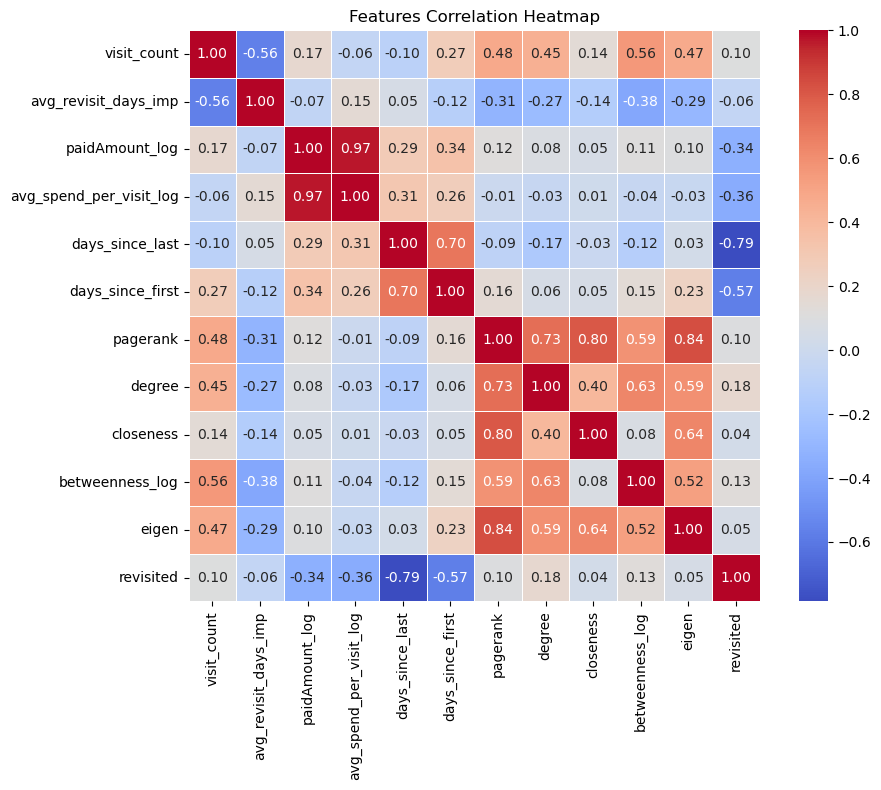

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# corr: pandas.DataFrame, numeric_df.corr() 로 구한 상관계수 행렬
plt.figure(figsize=(10,8))
sns.heatmap(df[feat_cols].corr(), 
            annot=True,        # 셀 안에 값 표시
            fmt=".2f",         # 소수점 둘째 자리 포맷
            cmap="coolwarm",   # 컬러맵
            linewidths=0.5,    # 셀 경계 두께
            square=True)       # 정사각형 셀
plt.title("Features Correlation Heatmap")
plt.tight_layout()
plt.show()

🧼 [결측치 비율 확인]

 - fullName: 0.1% △ 주의
 - phoneNumber: 0.5% △ 주의
 - dateOfBirth: 39.9% ⚠️ 높음
 - avg_revisit_days: 59.0% ⚠️ 높음
 - betweenness: 40.2% ⚠️ 높음
 - community: 40.2% ⚠️ 높음
 - paidAmount: 0.8% △ 주의
 - avg_spend_per_visit: 0.8% △ 주의

📊 [숫자형 변수 이상값 리포트]

📌 storeId
 - Median: 3.00
 - Max: 10028.00 / Min: 3.00
 - Mean ± 3*Std: [-10808.01, 17029.99]
   → ✅ 정상 범위 내
 - Z-score > 3: 0건
   → ✅ Z-score 이상 없음
 - IQR 범위: [-15034.50, 25065.50]
 - IQR 기준 이상값: 0건
   → ✅ IQR 기준 이상 없음



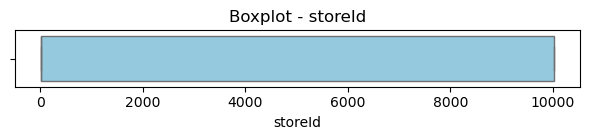

📌 visit_count
 - Median: 1.00
 - Max: 22.00 / Min: 1.00
 - Mean ± 3*Std: [-4.15, 8.08]
   → 🚨 이상값 의심됨 (3*표준편차 범위 초과)
 - Z-score > 3: 12건
   → 🚨 이상값 의심됨 (Z-score 기준)
 - IQR 범위: [-0.50, 3.50]
 - IQR 기준 이상값: 75건
   → 🚨 이상값 의심됨 (IQR 기준)



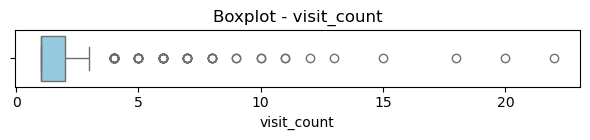

📌 avg_revisit_days
 - Median: 4.42
 - Max: 420.92 / Min: 0.00
 - Mean ± 3*Std: [-183.48, 248.18]
   → 🚨 이상값 의심됨 (3*표준편차 범위 초과)
 - Z-score > 3: 10건
   → 🚨 이상값 의심됨 (Z-score 기준)
 - IQR 범위: [-41.86, 70.86]
 - IQR 기준 이상값: 36건
   → 🚨 이상값 의심됨 (IQR 기준)



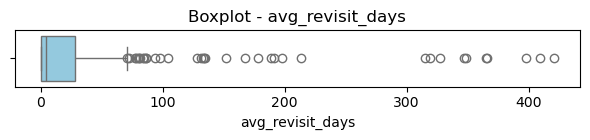

📌 pagerank
 - Median: 0.94
 - Max: 3.18 / Min: 0.00
 - Mean ± 3*Std: [-1.17, 2.42]
   → 🚨 이상값 의심됨 (3*표준편차 범위 초과)
 - Z-score > 3: 8건
   → 🚨 이상값 의심됨 (Z-score 기준)
 - IQR 범위: [-1.44, 2.40]
 - IQR 기준 이상값: 8건
   → 🚨 이상값 의심됨 (IQR 기준)



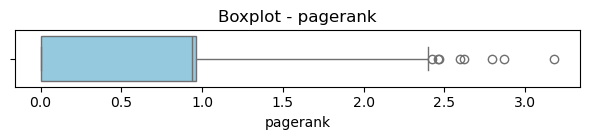

📌 degree
 - Median: 1.00
 - Max: 23.00 / Min: 0.00
 - Mean ± 3*Std: [-6.78, 10.54]
   → 🚨 이상값 의심됨 (3*표준편차 범위 초과)
 - Z-score > 3: 18건
   → 🚨 이상값 의심됨 (Z-score 기준)
 - IQR 범위: [-3.00, 5.00]
 - IQR 기준 이상값: 68건
   → 🚨 이상값 의심됨 (IQR 기준)



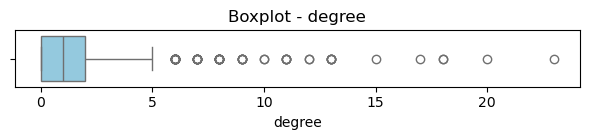

📌 betweenness
 - Median: 0.00
 - Max: 96264.00 / Min: 0.00
 - Mean ± 3*Std: [-14726.87, 15514.59]
   → 🚨 이상값 의심됨 (3*표준편차 범위 초과)
 - Z-score > 3: 3건
   → 🚨 이상값 의심됨 (Z-score 기준)
 - IQR 범위: [0.00, 0.00]
 - IQR 기준 이상값: 99건
   → 🚨 이상값 의심됨 (IQR 기준)



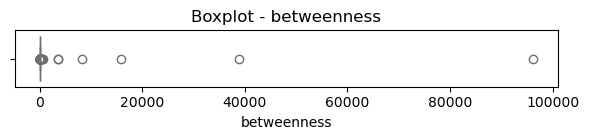

📌 closeness
 - Median: 0.55
 - Max: 1.00 / Min: 0.00
 - Mean ± 3*Std: [-0.86, 1.87]
   → ✅ 정상 범위 내
 - Z-score > 3: 0건
   → ✅ Z-score 이상 없음
 - IQR 범위: [-1.50, 2.50]
 - IQR 기준 이상값: 0건
   → ✅ IQR 기준 이상 없음



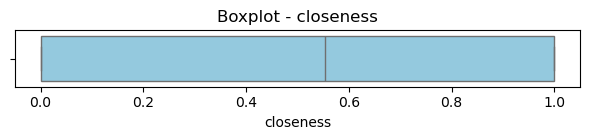

📌 eigen
 - Median: 0.01
 - Max: 0.08 / Min: 0.00
 - Mean ± 3*Std: [-0.02, 0.03]
   → 🚨 이상값 의심됨 (3*표준편차 범위 초과)
 - Z-score > 3: 11건
   → 🚨 이상값 의심됨 (Z-score 기준)
 - IQR 범위: [-0.01, 0.02]
 - IQR 기준 이상값: 32건
   → 🚨 이상값 의심됨 (IQR 기준)



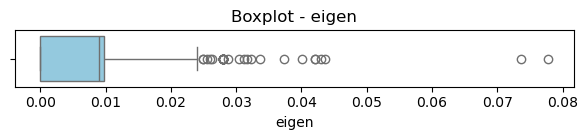

📌 community
 - Median: 6518.00
 - Max: 11566.00 / Min: 79.00
 - Mean ± 3*Std: [-5329.59, 16738.67]
   → ✅ 정상 범위 내
 - Z-score > 3: 0건
   → ✅ Z-score 이상 없음
 - IQR 범위: [-8362.50, 18691.50]
 - IQR 기준 이상값: 0건
   → ✅ IQR 기준 이상 없음



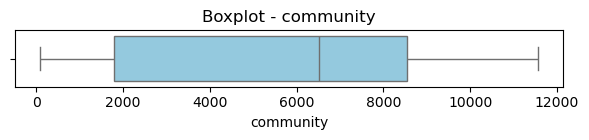

📌 paidAmount
 - Median: 21000.00
 - Max: 183700.00 / Min: 0.00
 - Mean ± 3*Std: [-38728.91, 91396.10]
   → 🚨 이상값 의심됨 (3*표준편차 범위 초과)
 - Z-score > 3: 12건
   → 🚨 이상값 의심됨 (Z-score 기준)
 - IQR 범위: [-20700.00, 64900.00]
 - IQR 기준 이상값: 38건
   → 🚨 이상값 의심됨 (IQR 기준)



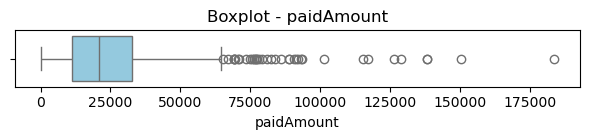

📌 days_since_first
 - Median: 175.00
 - Max: 633.00 / Min: 0.00
 - Mean ± 3*Std: [-153.75, 495.31]
   → 🚨 이상값 의심됨 (3*표준편차 범위 초과)
 - Z-score > 3: 20건
   → 🚨 이상값 의심됨 (Z-score 기준)
 - IQR 범위: [-112.50, 435.50]
 - IQR 기준 이상값: 26건
   → 🚨 이상값 의심됨 (IQR 기준)



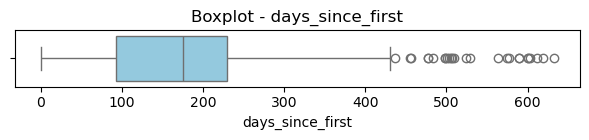

📌 days_since_last
 - Median: 152.00
 - Max: 595.00 / Min: 0.00
 - Mean ± 3*Std: [-108.87, 398.11]
   → 🚨 이상값 의심됨 (3*표준편차 범위 초과)
 - Z-score > 3: 4건
   → 🚨 이상값 의심됨 (Z-score 기준)
 - IQR 범위: [-135.50, 420.50]
 - IQR 기준 이상값: 4건
   → 🚨 이상값 의심됨 (IQR 기준)



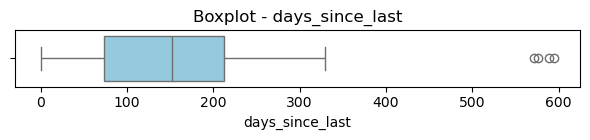

📌 revisited
 - Median: 0.00
 - Max: 1.00 / Min: 0.00
 - Mean ± 3*Std: [-1.07, 1.65]
   → ✅ 정상 범위 내
 - Z-score > 3: 0건
   → ✅ Z-score 이상 없음
 - IQR 범위: [-1.50, 2.50]
 - IQR 기준 이상값: 0건
   → ✅ IQR 기준 이상 없음



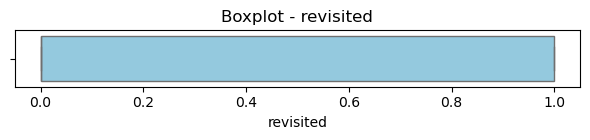

📌 paidAmount_log
 - Median: 9.95
 - Max: 12.12 / Min: 0.00
 - Mean ± 3*Std: [2.52, 16.42]
   → 🚨 이상값 의심됨 (3*표준편차 범위 초과)
 - Z-score > 3: 38건
   → 🚨 이상값 의심됨 (Z-score 기준)
 - IQR 범위: [7.66, 12.02]
 - IQR 기준 이상값: 39건
   → 🚨 이상값 의심됨 (IQR 기준)



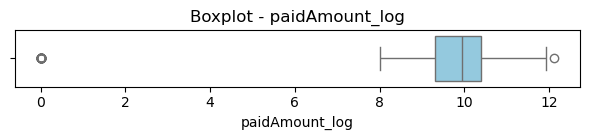

📌 betweenness_log
 - Median: 0.00
 - Max: 11.47 / Min: 0.00
 - Mean ± 3*Std: [-3.71, 4.62]
   → 🚨 이상값 의심됨 (3*표준편차 범위 초과)
 - Z-score > 3: 24건
   → 🚨 이상값 의심됨 (Z-score 기준)
 - IQR 범위: [0.00, 0.00]
 - IQR 기준 이상값: 99건
   → 🚨 이상값 의심됨 (IQR 기준)



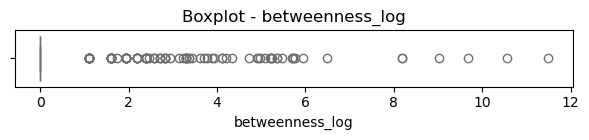

📌 avg_spend_per_visit
 - Median: 14900.00
 - Max: 67200.00 / Min: 0.00
 - Mean ± 3*Std: [-17911.12, 51036.81]
   → 🚨 이상값 의심됨 (3*표준편차 범위 초과)
 - Z-score > 3: 10건
   → 🚨 이상값 의심됨 (Z-score 기준)
 - IQR 범위: [-12350.00, 43250.00]
 - IQR 기준 이상값: 26건
   → 🚨 이상값 의심됨 (IQR 기준)



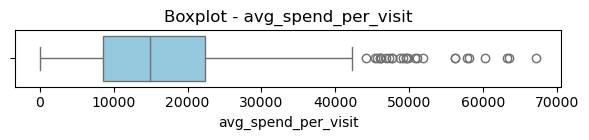

📌 avg_spend_per_visit_log
 - Median: 9.60
 - Max: 11.12 / Min: 0.00
 - Mean ± 3*Std: [2.39, 15.72]
   → 🚨 이상값 의심됨 (3*표준편차 범위 초과)
 - Z-score > 3: 38건
   → 🚨 이상값 의심됨 (Z-score 기준)
 - IQR 범위: [7.59, 11.47]
 - IQR 기준 이상값: 42건
   → 🚨 이상값 의심됨 (IQR 기준)



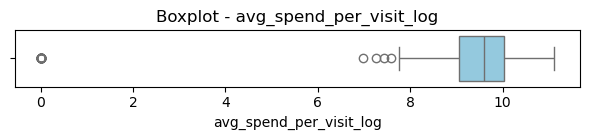

📌 avg_revisit_days_imp
 - Median: 420.92
 - Max: 420.92 / Min: 0.00
 - Mean ± 3*Std: [-328.60, 851.69]
   → ✅ 정상 범위 내
 - Z-score > 3: 0건
   → ✅ Z-score 이상 없음
 - IQR 범위: [-605.35, 1036.68]
 - IQR 기준 이상값: 0건
   → ✅ IQR 기준 이상 없음



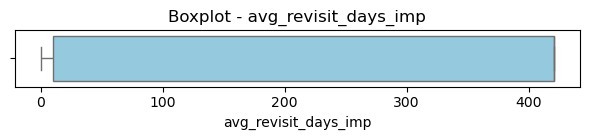


📦 [범주형 변수 희귀값 확인] (비율 < 1.0%)
 - customerId: 희귀값 729개 (100.0%) → ⚠️ 희귀 범주 존재
 - fullName: 희귀값 433개 (59.4%) → ⚠️ 희귀 범주 존재
 - phoneNumber: 희귀값 725개 (99.5%) → ⚠️ 희귀 범주 존재
 - dateOfBirth: 희귀값 438개 (60.1%) → ⚠️ 희귀 범주 존재
 - isMarketingAgreed: 희귀값 729개 (100.0%) → ⚠️ 희귀 범주 존재
 - first_visit: 희귀값 729개 (100.0%) → ⚠️ 희귀 범주 존재
 - last_visit: 희귀값 729개 (100.0%) → ⚠️ 희귀 범주 존재


In [5]:
detailed_outlier_report(df)

In [6]:
df.describe()

,storeId,visit_count,avg_revisit_days,pagerank,degree,betweenness,closeness,eigen,community,paidAmount,days_since_first,days_since_last,revisited,paidAmount_log,betweenness_log,avg_spend_per_visit,avg_spend_per_visit_log,avg_revisit_days_imp
count,729.000000,729.000000,299.000000,729.000000,729.000000,436.000000,729.000000,729.000000,436.000000,723.000000,729.000000,729.000000,729.000000,729.000000,729.000000,723.000000,729.000000,729.000000
mean,3110.989026,1.962963,32.349384,0.626491,1.876818,393.863150,0.502121,0.006828,5704.538991,26333.597510,170.780521,144.620027,0.289438,9.471143,0.451909,16562.845906,9.058719,261.546677
std,4639.666539,2.038773,71.944212,0.597681,2.887111,5040.243387,0.454547,0.008240,3678.043580,21687.502417,108.175192,84.496974,0.453813,2.316805,1.388144,11491.322604,2.221371,196.714406
min,3.000000,1.000000,0.000689,0.000000,0.000000,0.000000,0.000000,0.000000,79.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000689
25%,3.000000,1.000000,0.409453,0.000000,0.000000,0.000000,0.000000,0.000000,1782.750000,11400.000000,93.000000,73.000000,0.000000,9.296610,0.000000,8500.000000,9.047939,10.413223
50%,3.000000,1.000000,4.419770,0.935104,1.000000,0.000000,0.554348,0.009046,6518.000000,21000.000000,175.000000,152.000000,0.000000,9.947552,0.000000,14900.000000,9.595671,420.918749
75%,10028.000000,2.000000,28.589208,0.961240,2.000000,0.000000,1.000000,0.009745,8546.250000,32800.000000,230.000000,212.000000,1.000000,10.385945,0.000000,22400.000000,10.016861,420.918749
max,10028.000000,22.000000,420.918749,3.180597,23.000000,96264.000000,1.000000,0.077768,11566.000000,183700.000000,633.000000,595.000000,1.000000,12.121065,11.474860,67200.000000,11.115443,420.918749


In [7]:
df.sort_values('betweenness',ascending=False)

,customerId,fullName,phoneNumber,dateOfBirth,isMarketingAgreed,storeId,visit_count,first_visit,last_visit,avg_revisit_days,...,community,paidAmount,days_since_first,days_since_last,revisited,paidAmount_log,betweenness_log,avg_spend_per_visit,avg_spend_per_visit_log,avg_revisit_days_imp
601,01JNZSJ8S4EW5DVC9MJXYZ8AF0,안*민,************9128,2006-07-19,2025-03-19 09:28:13,10028,6,2025-03-10 10:28:03.919336,2025-05-13 09:11:55.276860,12.789424,...,5183.0,117019.0,64,0,1,11.670100,11.474860,19503.166667,9.878383,12.789424
288,01JAY33R5XQ9A6ZXNY9WF2P81X,이*빈,************3373,2005-12-22,2024-11-06 03:36:11,10028,8,2024-10-24 01:44:11.002804,2025-03-21 13:05:13.195023,21.210420,...,5567.0,93019.0,201,53,1,11.440570,10.565944,11627.375000,9.361204,21.210420
401,01JDPA7N5349FHRTRJXH1HBM74,김*현,************1905,2002-07-10,2025-04-13 12:29:28,10028,11,2024-11-27 08:01:22.854304,2025-03-14 05:34:54.030795,10.689828,...,4445.0,129060.0,167,60,1,11.768040,9.674389,11732.727273,9.370223,10.689828
391,01JDE94SDGZGA6ZEMNTCBT6D0E,박*영,************9117,2005-07-04,2024-11-24 05:12:02,10028,3,2024-11-24 05:08:19.737928,2025-01-06 08:22:34.695546,21.567448,...,6337.0,60250.0,170,127,0,11.006274,9.014812,20083.333333,9.907695,21.567448
208,01J9AQFPM25TFH2NM6CR0ZE73Y,주*빈,************7511,2003-12-24,2024-10-04 03:01:33,10028,2,2024-10-04 02:59:41.485208,2025-03-20 09:07:15.455327,167.255254,...,6846.0,22400.0,221,54,1,10.016861,8.172164,11200.000000,9.323758,167.255254
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
709,01JTDEKEAQ1PSRBKG32GG742EC,G***t,**********5359,NaN,2025-05-04 10:52:52,3,1,2025-05-04 10:48:50.796719,2025-05-04 10:48:50.796719,NaN,...,NaN,0.0,9,9,1,0.000000,0.000000,0.000000,0.000000,420.918749
712,01JTFD0V8M0RE73RJR2VQZJPYZ,G***t,**********5020,NaN,2025-05-05 05:04:01,3,1,2025-05-05 04:59:41.739919,2025-05-05 04:59:41.739919,NaN,...,NaN,24800.0,8,8,1,10.118639,0.000000,24800.000000,10.118639,420.918749
713,01JTFET5YY8ZJT9SW33PK4P3JJ,G***t,**********9989,NaN,2025-05-08 11:06:05,3,1,2025-05-08 11:02:55.883697,2025-05-08 11:02:55.883697,NaN,...,NaN,3000.0,5,5,1,8.006701,0.000000,3000.000000,8.006701,420.918749
718,01JTTFSDZ81GN27S0FRA00ZZ14,G***t,**********2216,NaN,2025-05-09 12:21:47,3,1,2025-05-09 12:19:43.256610,2025-05-09 12:19:43.256610,NaN,...,NaN,14400.0,4,4,1,9.575053,0.000000,14400.000000,9.575053,420.918749


In [8]:
results = []

for sid, g in df.groupby('storeId'):
    X = g[feat_cols].values

    scaler = RobustScaler(quantile_range=(20,80))
    X_std = scaler.fit_transform(X)

    # ── 적절한 k 찾기 (실험적으로 2~8 범위 순회 → silhouette 최고 k 선택)
    best_k, best_score = None, -1
    for k in range(2, 9):
        km = KMeans(n_clusters=k, n_init='auto', random_state=42)
        labels = km.fit_predict(X_std)
        score = silhouette_score(X_std, labels)
        if score > best_score:
            best_k, best_score, best_labels, best_km = k, score, labels, km
    
    print(f"[store {sid}]  best_k={best_k}, silhouette={best_score:.3f}")
    
    # 군집 라벨 붙이기
    seg = g.copy()
    seg['cluster'] = best_labels
    results.append(seg)

segmented = pd.concat(results)

[store 3]  best_k=2, silhouette=0.757
[store 5]  best_k=2, silhouette=0.664
[store 10028]  best_k=2, silhouette=0.701


C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\sklearn\cluster\_kmeans.py:1382: User

**1. StandardScaler** (결측치 평균)

| Store | Best k | Silhouette |
| ----- | ------ | ---------- |
| 3     | 2      | 0.498      |
| 5     | 3      | 0.341      |
| 10028 | 2      | 0.725      |

**2. RobustScaler** (paidAmount log)

| Store | Best k | Silhouette |
| ----- | ------ | ---------- |
| 3     | 4      | 0.626      |
| 5     | 2      | 0.380      |
| 10028 | 2      | 0.969      |

**3. RobustScaler** (paidAmount + betweenness log)

| Store | Best k | Silhouette |
| ----- | ------ | ---------- |
| 3     | 3      | 0.628      |
| 5     | 2      | 0.542      |
| 10028 | 2      | 0.635      |


**4. StandardScaler** (3개 모두 log)

| Store | Best k | Silhouette |
| ----- | ------ | ---------- |
| 3     | 2      | 0.541      |
| 5     | 2      | 0.408      |
| 10028 | 2      | 0.743      |


**5. StandardScaler** (결측치 제거 각각 다르게)

| Store | Best k | Silhouette |
| ----- | ------ | ---------- |
| 3     | 8      | 0.335      |
| 5     | 8      | 0.341      |
| 10028 | 7      | 0.331      |

**6. RobustScaler** (결측치 제거 각각 다르게)

| Store | Best k | Silhouette |
| ----- | ------ | ---------- |
| 3     | 2      | 0.716      |
| 5     | 2      | 0.546      |
| 10028 | 2      | 0.719      |

**7. RobustScaler** (quantile_range=(10,90))

| Store | Best k | Silhouette |
| ----- | ------ | ---------- |
| 3     | 2      | 0.670      |
| 5     | 2      | 0.588      |
| 10028 | 2      | 0.702      |

**8. RobustScaler** (quantile_range=(20,80))

| Store | Best k | Silhouette |
| ----- | ------ | ---------- |
| 3     | 3      | 0.666      |
| 5     | 2      | 0.561      |
| 10028 | 2      | 0.778      |

### **---------------1회당 지출금액 추가!!!---------------**
<br>
<br>

**9. StandardScaler** (결측치 제거 각각 다르게)

| Store | Best k | Silhouette |
| ----- | ------ | ---------- |
| 3     | 4      | 0.374      |
| 5     | 2      | 0.423      |
| 10028 | 7      | 0.343      |

**10. RobustScaler** (결측치 제거 각각 다르게)

| Store | Best k | Silhouette |
| ----- | ------ | ---------- |
| 3     | 2      | **0.789**      |
| 5     | 2      | 0.677      |
| 10028 | 2      | 0.686      |

**11. RobustScaler** (quantile_range=(10,90))

| Store | Best k | Silhouette |
| ----- | ------ | ---------- |
| 3     | 2      | 0.741      |
| 5     | 2      | **0.700**      |
| 10028 | 6      | 0.318      |

**12. RobustScaler** (quantile_range=(20,80))

| Store | Best k | Silhouette |
| ----- | ------ | ---------- |
| 3     | 2      | 0.757      |
| 5     | 2      | 0.664      |
| 10028 | 2      | **0.701**      |

In [9]:
profile = (
    segmented
    .groupby(['storeId','cluster'])[feat_cols]
    .median()
    .round(5)
)
pd.DataFrame(profile)

visit_count  avg_revisit_days_imp  paidAmount_log  \
storeId cluster                                                      
3       0                1.0             420.91875         9.79261   
        1                1.0             420.91875         0.00000   
5       0                2.0              70.78965         9.48805   
        1                1.0             420.91875         0.00000   
10028   0                5.5              11.78067        11.10071   
        1                1.0             420.91875        10.25229   

                 avg_spend_per_visit_log  days_since_last  days_since_first  \
storeId cluster                                                               
3       0                        9.29200            120.0             139.5   
        1                        0.00000             42.0              42.0   
5       0                        8.79498            151.0             159.0   
        1                        0.00000             96.5              96.5   
10028   0                        9.34248            100.5             208.0   
        1                       10.10033            210.5             216.5   

                 pagerank  degree  closeness  betweenness_log    eigen  
storeId cluster                                                         
3       0         0.85870     1.0    0.53846          0.00000  0.00739  
        1         0.68525     1.0    0.45417          0.00000  0.00586  
5       0         0.96124     1.0    0.70000          0.00000  0.02805  
        1         0.48062     1.5    0.50000          0.00000  0.01403  
10028   0         1.61490     6.5    0.71667          3.98295  0.01648  
        1         0.74095     1.0    0.60000          0.00000  0.00731

<Axes: ylabel='storeId-cluster'>

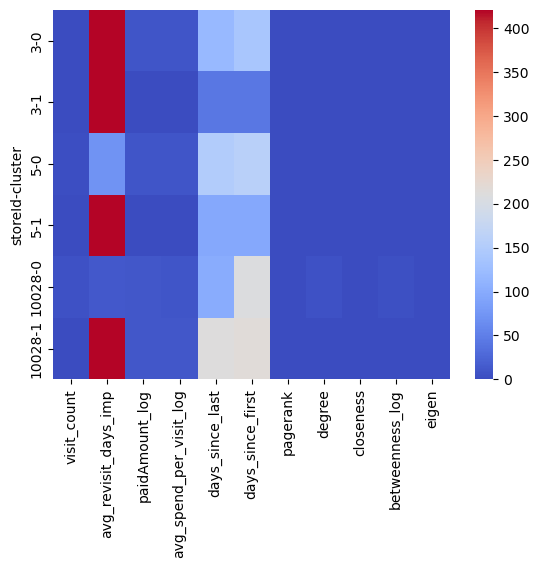

In [21]:
sns.heatmap(profile, cmap='coolwarm')

In [11]:
segmented[segmented['storeId']==3].groupby('cluster').count()

,customerId,fullName,phoneNumber,dateOfBirth,isMarketingAgreed,storeId,visit_count,first_visit,last_visit,avg_revisit_days,...,community,paidAmount,days_since_first,days_since_last,revisited,paidAmount_log,betweenness_log,avg_spend_per_visit,avg_spend_per_visit_log,avg_revisit_days_imp
cluster,,,,,,,,,,,,,,,,,,,,,
0,430,429,426,262,430,430,430,430,430,172,...,248,430,430,430,430,430,430,430,430,430
1,36,36,36,18,36,36,36,36,36,17,...,22,32,36,36,36,36,36,32,36,36


In [12]:
segmented[segmented['storeId']==5].groupby('cluster').count()

,customerId,fullName,phoneNumber,dateOfBirth,isMarketingAgreed,storeId,visit_count,first_visit,last_visit,avg_revisit_days,...,community,paidAmount,days_since_first,days_since_last,revisited,paidAmount_log,betweenness_log,avg_spend_per_visit,avg_spend_per_visit_log,avg_revisit_days_imp
cluster,,,,,,,,,,,,,,,,,,,,,
0,35,35,35,31,35,35,35,35,35,20,...,24,35,35,35,35,35,35,35,35,35
1,2,2,2,1,2,2,2,2,2,0,...,1,0,2,2,2,2,2,0,2,2


In [13]:
segmented[segmented['storeId']==10028].groupby('cluster').count()

,customerId,fullName,phoneNumber,dateOfBirth,isMarketingAgreed,storeId,visit_count,first_visit,last_visit,avg_revisit_days,...,community,paidAmount,days_since_first,days_since_last,revisited,paidAmount_log,betweenness_log,avg_spend_per_visit,avg_spend_per_visit_log,avg_revisit_days_imp
cluster,,,,,,,,,,,,,,,,,,,,,
0,14,14,14,13,14,14,14,14,14,14,...,14,14,14,14,14,14,14,14,14,14
1,212,212,212,113,212,212,212,212,212,76,...,127,212,212,212,212,212,212,212,212,212


In [14]:
# !pip install k-means-constrained
# !pip install scikit-learn-extra